In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import auc


In [2]:
def compute_auc_and_std(data, nb_episodes):
    # data = np.load(filepath, allow_pickle=True)
    all_returns = data['episode_rewards']  # shape: (n_seeds, n_episodes)
    # print("all_returns ", all_returns, "\n")
    
    # print("all_returns shape:", all_returns.shape, "\n")
    aucs = []
    for rewards in all_returns:
        returns = rewards[:nb_episodes]
        x = np.arange(len(returns))
        aucs.append(auc(x, returns))

    auc_mean = np.mean(aucs)
    auc_std = np.std(aucs)
    return auc_mean, auc_std



In [3]:
prob = "CartPole"
window_size = 10
nb_episodes = 300

In [4]:
base_path = f"C:\\Users\\nicle\\Desktop\\\Master-thesis-clean-code\\Results\\{prob}"



### Plot subfigures



In [6]:
CP_comparison_dict_auc_mean = {}
CP_comparison_dict_auc_std = {}


QRNN-ASNN-PF-Mid: AUC = 59305.33 ± 699.56 

QRNN-basic-PF-Mid: AUC = 59243.67 ± 786.77 

QRNN-rnd-PF-Mid: AUC = 59424.00 ± 531.74 

QRNN-RS-Mid: AUC = 59418.67 ± 539.29 

############################################################# 

QRNN-ASNN-CEM-Mid: AUC = 59216.00 ± 825.90 

QRNN-basic-CEM-Mid: AUC = 59053.50 ± 1055.71 

QRNN-rnd-CEM-Mid: AUC = 59197.00 ± 852.77 

############################################################# 

QRNN-ASNN-PF-Sampling: AUC = 6682.83 ± 153.14 

QRNN-basic-PF-Sampling: AUC = 6607.67 ± 128.83 

QRNN-rnd-PF-Sampling: AUC = 6615.33 ± 216.13 

QRNN-RS-Sampling: AUC = 6822.00 ± 177.29 

############################################################# 

QRNN-ASNN-CEM-Sampling: AUC = 6909.67 ± 104.44 

QRNN-basic-CEM-Sampling: AUC = 7051.00 ± 241.24 

QRNN-rnd-CEM-Sampling: AUC = 6890.67 ± 207.93 



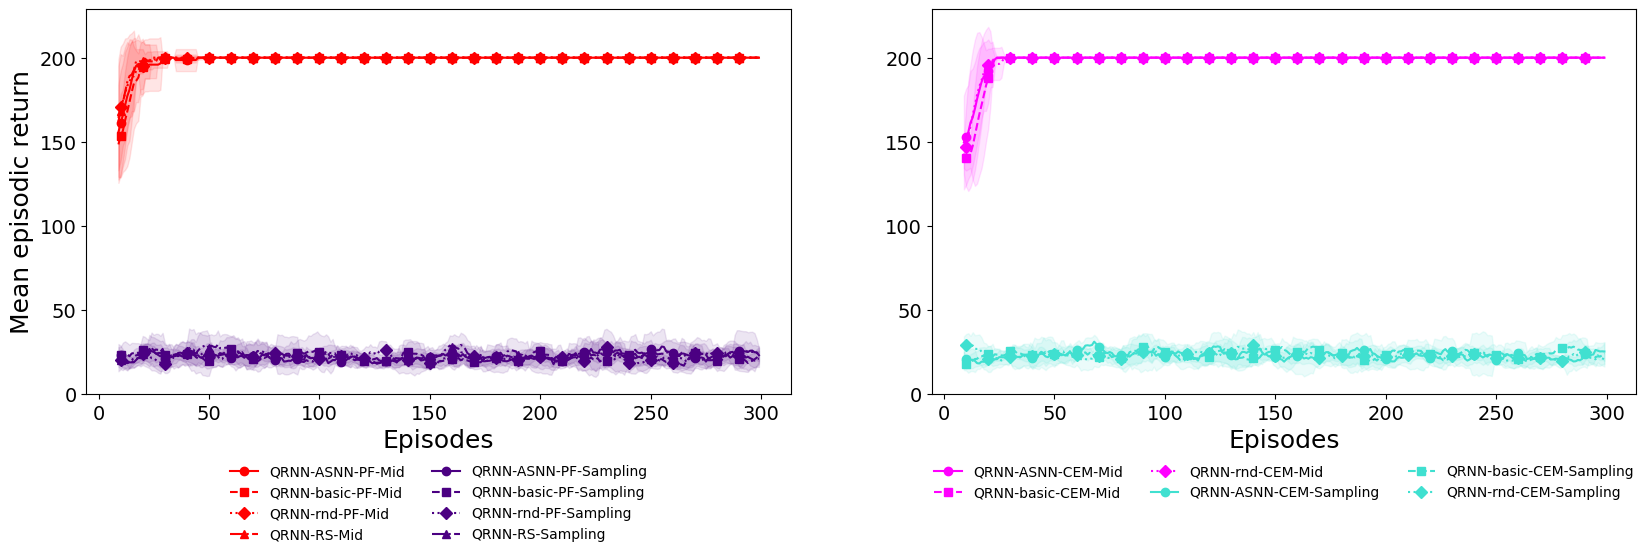

In [16]:
fig, axs = plt.subplots(1,2, figsize=(20, 5), sharey=True)
plt.rcParams.update({'font.size': 20})
for i, ax in enumerate(axs):
    # ax.plot([1, 2, 3], [j*(i+1) for j in [1, 4, 9]])
    # ax.set_title(f"Plot {i+1}", fontsize=20)
    ax.set_xlabel("Episodes", fontsize=18)
    ax.tick_params(axis='both', labelsize=14)
    ax.yaxis.set_tick_params(labelleft=True)

axs[0].set_ylabel("Mean episodic return", fontsize=18)

############################# QRNN-PF-Using mid quantile ############################

QRNN = {'QRNN-ASNN-PF-Mid': f'{base_path}\\{prob}_MPC_QRNN_ASGNN_mid_June25.npz',
    'QRNN-basic-PF-Mid': f'{base_path}\\{prob}_MPC_QRNN_basic_mid_May6.npz',
    'QRNN-rnd-PF-Mid': f'{base_path}\\{prob}_MPC_QRNN_random_mid_May6.npz',
    'QRNN-RS-Mid': f'{base_path}\\{prob}_RS_mid_QRNN_May6.npz',}
color = 'red'
# Assign markers and linestyles to sub-methods
markers = ['o', 's', 'D', '^', 'v', 'x', '*']  # Add more if needed
linestyles = ['-', '--', ':', '-.', (0, (3, 1, 1, 1))]  # Custom patterns
it = 0
for label, filepath in QRNN.items():
    data = np.load(filepath)
    mean_rewards = data['mean_rewards'][:nb_episodes]
    std_rewards = data['std_rewards'][:nb_episodes]
    
    if len(mean_rewards) < nb_episodes:
        print(f"Warning: {label} has fewer than {nb_episodes} episodes. Skipping this method.")
        continue
    if len(std_rewards) < nb_episodes:
        print(f"Warning: {label} has fewer than {nb_episodes} episodes. Skipping this method.")
        continue
    
    auc_mean, auc_std = compute_auc_and_std(data, nb_episodes)
    print(f"{label}: AUC = {auc_mean:.2f} ± {auc_std:.2f} \n")
    CP_comparison_dict_auc_mean[label] = auc_mean
    CP_comparison_dict_auc_std[label] = auc_std

    # if it == 0:
    #     print(mean_rewards)
    #     print(std_rewards)
    
    # Smooth the data
    smoothed_mean = pd.Series(mean_rewards).rolling(window=window_size).mean()
    smoothed_std = pd.Series(std_rewards).rolling(window=window_size).std()
    
    # Plot
    axs[0].plot(smoothed_mean, 
             label=f"{label}", 
             color=color,
             marker=markers[it],
             linestyle=linestyles[it],
             markevery=10)  # Show markers every 10 points
    
    # Confidence interval (optional)
    axs[0].fill_between(range(len(mean_rewards)), 
                     smoothed_mean - smoothed_std, 
                     smoothed_mean + smoothed_std, 
                     color=color, alpha=0.1)
    it += 1
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

############################# QRNN-CEM-Using mid quantile ############################

print("############################################################# \n")

QRNN_CEM = {'QRNN-ASNN-CEM-Mid': f'{base_path}\\{prob}_MPC_QRNN_ASGNN_mid_June25_CEM.npz',
    'QRNN-basic-CEM-Mid': f'{base_path}\\{prob}_MPC_QRNN_basic_mid_May6_CEM.npz',
    'QRNN-rnd-CEM-Mid': f'{base_path}\\{prob}_MPC_QRNN_random_mid_May6_CEM.npz',}
color = 'magenta'
# Assign markers and linestyles to sub-methods
markers = ['o', 's', 'D', '^', 'v', 'x', '*']  # Add more if needed
linestyles = ['-', '--', ':', '-.', (0, (3, 1, 1, 1))]  # Custom patterns
it = 0
for label, filepath in QRNN_CEM.items():
    data = np.load(filepath)
    mean_rewards = data['mean_rewards'][:nb_episodes]
    std_rewards = data['std_rewards'][:nb_episodes]
    
    if len(mean_rewards) < nb_episodes:
        print(f"Warning: {label} has fewer than {nb_episodes} episodes. Skipping this method.")
        continue
    if len(std_rewards) < nb_episodes:
        print(f"Warning: {label} has fewer than {nb_episodes} episodes. Skipping this method.")
        continue
    
    auc_mean, auc_std = compute_auc_and_std(data, nb_episodes)
    print(f"{label}: AUC = {auc_mean:.2f} ± {auc_std:.2f} \n")
    CP_comparison_dict_auc_mean[label] = auc_mean
    CP_comparison_dict_auc_std[label] = auc_std

    # if it == 0:
    #     print(mean_rewards)
    #     print(std_rewards)
    
    # Smooth the data
    smoothed_mean = pd.Series(mean_rewards).rolling(window=window_size).mean()
    smoothed_std = pd.Series(std_rewards).rolling(window=window_size).std()
    
    # Plot
    axs[1].plot(smoothed_mean, 
             label=f"{label}", 
             color=color,
             marker=markers[it],
             linestyle=linestyles[it],
             markevery=10)  # Show markers every 10 points
    
    # Confidence interval (optional)
    axs[1].fill_between(range(len(mean_rewards)), 
                     smoothed_mean - smoothed_std, 
                     smoothed_mean + smoothed_std, 
                     color=color, alpha=0.1)
    it += 1
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

print("############################################################# \n")

############################# QRNN-PF-Using mid quantile ############################

QRNN_Sampling = {'QRNN-ASNN-PF-Sampling': f'{base_path}\\{prob}_MPC_QRNN_ASNN_Sampling_July31.npz',
    'QRNN-basic-PF-Sampling': f'{base_path}\\{prob}_MPC_QRNN_basic_Sampling_July31.npz',
    'QRNN-rnd-PF-Sampling': f'{base_path}\\{prob}_MPC_QRNN_random_Sampling_July31.npz',
    'QRNN-RS-Sampling': f'{base_path}\\{prob}_RS_Sampling_QRNN_July31.npz',}
color = 'indigo'
# Assign markers and linestyles to sub-methods
markers = ['o', 's', 'D', '^', 'v', 'x', '*']  # Add more if needed
linestyles = ['-', '--', ':', '-.', (0, (3, 1, 1, 1))]  # Custom patterns
it = 0
for label, filepath in QRNN_Sampling.items():
    data = np.load(filepath)
    mean_rewards = data['mean_rewards'][:nb_episodes]
    std_rewards = data['std_rewards'][:nb_episodes]
    
    if len(mean_rewards) < nb_episodes:
        print(f"Warning: {label} has fewer than {nb_episodes} episodes. Skipping this method.")
        continue
    if len(std_rewards) < nb_episodes:
        print(f"Warning: {label} has fewer than {nb_episodes} episodes. Skipping this method.")
        continue
    
    auc_mean, auc_std = compute_auc_and_std(data, nb_episodes)
    print(f"{label}: AUC = {auc_mean:.2f} ± {auc_std:.2f} \n")
    CP_comparison_dict_auc_mean[label] = auc_mean
    CP_comparison_dict_auc_std[label] = auc_std

    # if it == 0:
    #     print(mean_rewards)
    #     print(std_rewards)
    
    # Smooth the data
    smoothed_mean = pd.Series(mean_rewards).rolling(window=window_size).mean()
    smoothed_std = pd.Series(std_rewards).rolling(window=window_size).std()
    
    # Plot
    axs[0].plot(smoothed_mean, 
             label=f"{label}", 
             color=color,
             marker=markers[it],
             linestyle=linestyles[it],
             markevery=10)  # Show markers every 10 points
    
    # Confidence interval (optional)
    axs[0].fill_between(range(len(mean_rewards)), 
                     smoothed_mean - smoothed_std, 
                     smoothed_mean + smoothed_std, 
                     color=color, alpha=0.1)
    it += 1
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

axs[0].legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, fontsize=10, frameon=False)

############################# QRNN-CEM-Using mid quantile ############################

print("############################################################# \n")

QRNN_CEM = {'QRNN-ASNN-CEM-Sampling': f'{base_path}\\{prob}_MPC_QRNN_ASNN_Sampling_July31_CEM.npz',
    'QRNN-basic-CEM-Sampling': f'{base_path}\\{prob}_MPC_QRNN_basic_Sampling_July31_CEM.npz',
    'QRNN-rnd-CEM-Sampling': f'{base_path}\\{prob}_MPC_QRNN_random_Sampling_July31_CEM.npz',}
color = 'turquoise'
# Assign markers and linestyles to sub-methods
markers = ['o', 's', 'D', '^', 'v', 'x', '*']  # Add more if needed
linestyles = ['-', '--', ':', '-.', (0, (3, 1, 1, 1))]  # Custom patterns
it = 0
for label, filepath in QRNN_CEM.items():
    data = np.load(filepath)
    mean_rewards = data['mean_rewards'][:nb_episodes]
    std_rewards = data['std_rewards'][:nb_episodes]
    
    if len(mean_rewards) < nb_episodes:
        print(f"Warning: {label} has fewer than {nb_episodes} episodes. Skipping this method.")
        continue
    if len(std_rewards) < nb_episodes:
        print(f"Warning: {label} has fewer than {nb_episodes} episodes. Skipping this method.")
        continue
    
    auc_mean, auc_std = compute_auc_and_std(data, nb_episodes)
    print(f"{label}: AUC = {auc_mean:.2f} ± {auc_std:.2f} \n")
    CP_comparison_dict_auc_mean[label] = auc_mean
    CP_comparison_dict_auc_std[label] = auc_std

    # if it == 0:
    #     print(mean_rewards)
    #     print(std_rewards)
    
    # Smooth the data
    smoothed_mean = pd.Series(mean_rewards).rolling(window=window_size).mean()
    smoothed_std = pd.Series(std_rewards).rolling(window=window_size).std()
    
    # Plot
    axs[1].plot(smoothed_mean, 
             label=f"{label}", 
             color=color,
             marker=markers[it],
             linestyle=linestyles[it],
             markevery=10)  # Show markers every 10 points
    
    # Confidence interval (optional)
    axs[1].fill_between(range(len(mean_rewards)), 
                     smoothed_mean - smoothed_std, 
                     smoothed_mean + smoothed_std, 
                     color=color, alpha=0.1)
    it += 1
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# axs[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left',ncol=2)
axs[1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, fontsize=10, frameon=False)



In [28]:
sorted_dict = dict(sorted(CP_dict_auc_mean.items(), key=lambda item: item[1], reverse=True)[:6])
sorted_dict


{'50NN-rnd-CEM': 59543.0,
 'QRNN-rnd-PF': 59424.0,
 'QRNN-RS': 59418.666666666664,
 '50NN-ASNN-CEM': 59399.833333333336,
 'QRNN-ASNN-PF': 59305.333333333336,
 'MSENN-basic-PF': 59295.0}

In [29]:
CP_dict_auc_mean, CP_dict_auc_std


({'QRNN-ASNN-PF': 59305.333333333336,
  'QRNN-basic-PF': 59243.666666666664,
  'QRNN-rnd-PF': 59424.0,
  'QRNN-RS': 59418.666666666664,
  '50NN-ASNN-PF': 59216.166666666664,
  '50NN-basic-PF': 2591.3333333333335,
  '50NN-rnd-PF': 58768.666666666664,
  '50NN-RS': 59235.166666666664,
  'MSENN-ASNN-PF': 59120.666666666664,
  'MSENN-basic-PF': 59295.0,
  'MSENN-rnd-PF': 59091.833333333336,
  'MSENN-RS': 59104.0,
  'QRNN-ASNN-CEM': 59216.0,
  'QRNN-basic-CEM': 59053.5,
  'QRNN-rnd-CEM': 59197.0,
  '50NN-ASNN-CEM': 59399.833333333336,
  '50NN-basic-CEM': 3192.0,
  '50NN-rnd-CEM': 59543.0,
  'MSENN-ASNN-CEM': 58903.0,
  'MSENN-basic-CEM': 59156.0,
  'MSENN-rnd-CEM': 58964.666666666664,
  'DQN': 17194.333333333332,
  'IV-DQN': 22942.166666666668,
  'QR-DQN': 36698.833333333336,
  'A2C': 26731.0,
  'PPO': 40018.166666666664},
 {'QRNN-ASNN-PF': 699.564308853891,
  'QRNN-basic-PF': 786.7741452002319,
  'QRNN-rnd-PF': 531.7442994522837,
  'QRNN-RS': 539.2867717849402,
  '50NN-ASNN-PF': 794.0577574

In [ ]:
import json

# writing dictionary to a file as JSON
with open('C:\\Users\\nicle\\Desktop\\Master-thesis-clean-code\\AUC_data\\\\CP_auc_mean.json', 'w') as f:
    json.dump(CP_comparison_dict_auc_mean, f)

with open('C:\\Users\\nicle\\Desktop\\Master-thesis-clean-code\\AUC_data\\CP_auc_std.json', 'w') as f:
    json.dump(CP_comparison_dict_auc_std, f)


In [ ]:
for key, value in CP_comparison_dict_auc_mean.items():
    print(f"{key}: {value:.2f} ± {CP_comparison_dict_auc_std[key]:.2f}")
    

QRNN-ASNN-PF: 59305.33 ± 699.56
QRNN-basic-PF: 59243.67 ± 786.77
QRNN-rnd-PF: 59424.00 ± 531.74
QRNN-RS: 59418.67 ± 539.29
50NN-ASNN-PF: 59216.17 ± 794.06
50NN-basic-PF: 2591.33 ± 140.95
50NN-rnd-PF: 58768.67 ± 1458.53
50NN-RS: 59235.17 ± 798.79
MSENN-ASNN-PF: 59120.67 ± 829.56
MSENN-basic-PF: 59295.00 ± 714.18
MSENN-rnd-PF: 59091.83 ± 841.48
MSENN-RS: 59104.00 ± 954.75
QRNN-ASNN-CEM: 59216.00 ± 825.90
QRNN-basic-CEM: 59053.50 ± 1055.71
QRNN-rnd-CEM: 59197.00 ± 852.77
50NN-ASNN-CEM: 59399.83 ± 565.92
50NN-basic-CEM: 3192.00 ± 146.33
50NN-rnd-CEM: 59543.00 ± 363.45
MSENN-ASNN-CEM: 58903.00 ± 838.72
MSENN-basic-CEM: 59156.00 ± 841.36
MSENN-rnd-CEM: 58964.67 ± 1137.78
DQN: 17194.33 ± 218.63
IV-DQN: 22942.17 ± 1869.13
QR-DQN: 36698.83 ± 22378.26
A2C: 26731.00 ± 4120.32
PPO: 40018.17 ± 3158.19
